# 00 · Quick start

`foresight_gpu` turns a deterministic model into a **reliable probabilistic forecast** using the Generalized Pareto Uncertainty (GPU) method. The public interface is a scikit-learn regressor.

- `predict(X)` → point estimate (median band)
- `predict_quantiles(X)` → probabilistic bands

In [1]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from foresight_gpu import GPURegressor
from foresight_gpu.utils import plot_timeseries, plot_qq
from foresight_gpu.metrics.probabilistic import reliability
from foresight_gpu.models import MLPModel
import pandas as pd
%matplotlib widget

FIG_DIR = Path('TestMLPfigures')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    """Pickle a Figure so it can be reopened interactively later (see load_fig)."""
    path = FIG_DIR / f'{name}.pkl'
    with open(path, 'wb') as fh:
        pickle.dump(fig, fh)
    return path


def load_fig(name):
    """Unpickle a Figure and attach it to a fresh pyplot canvas.

    A pickled figure carries no canvas/manager, so it renders nothing until it is
    bound to one owned by the current backend (widget, inline, qt, ...).
    """
    with open(FIG_DIR / f'{name}.pkl', 'rb') as fh:
        fig = pickle.load(fh)
    manager = plt.figure().canvas.manager
    manager.canvas.figure = fig
    fig.set_canvas(manager.canvas)
    return fig

### A heteroscedastic toy problem

In [ ]:
rng = np.random.default_rng(0)
n = 3000
x = np.linspace(0, 1, n)
signal = np.sin(2 * np.pi * x)
# noise = (0.2 + 0.6 * x) * rng.standard_normal(n)  # spread grows with x
X = x[:, None]
y = signal #+ noise

Running experiment T1


c:\Users\ruism\.conda\envs\foresight_gpu\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


saved -> TestMLPfigures\T1_bands_qq.pkl
Running experiment T2


c:\Users\ruism\.conda\envs\foresight_gpu\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


saved -> TestMLPfigures\T2_bands_qq.pkl
Running experiment T3


c:\Users\ruism\.conda\envs\foresight_gpu\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


saved -> TestMLPfigures\T3_bands_qq.pkl
Running experiment T4


c:\Users\ruism\.conda\envs\foresight_gpu\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


saved -> TestMLPfigures\T4_bands_qq.pkl


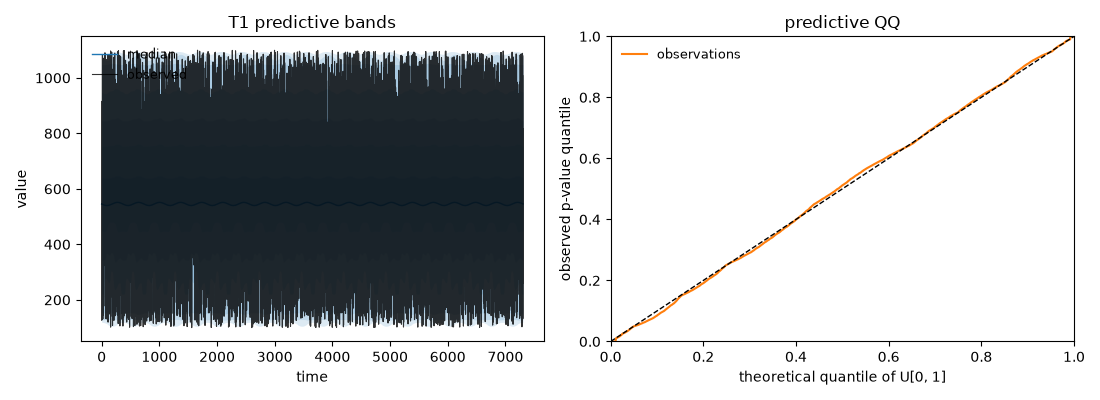

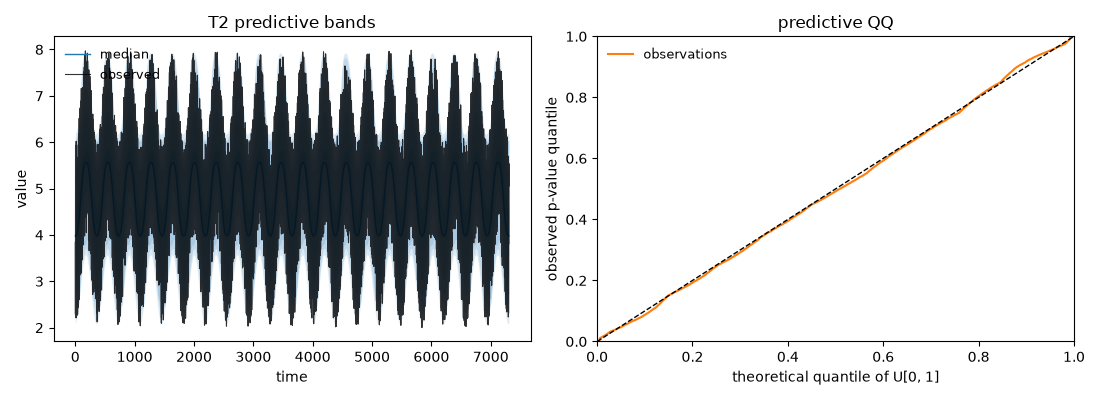

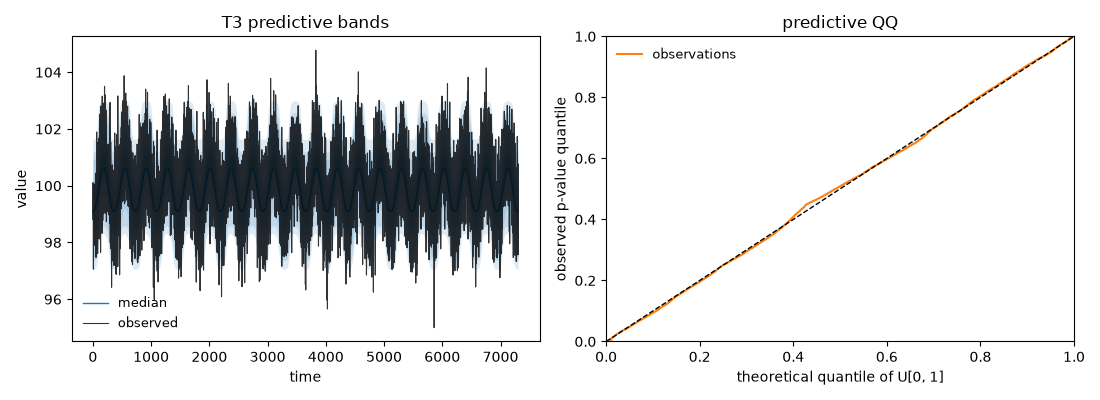

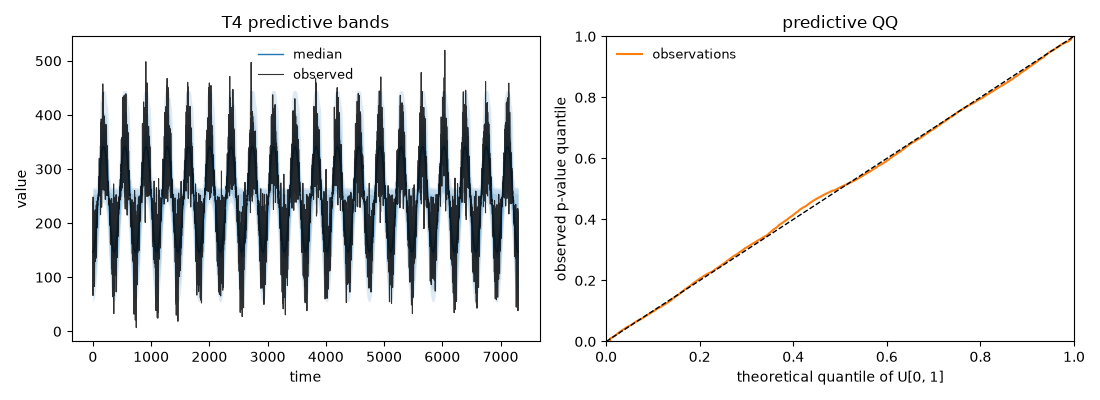

In [ ]:
# New toy problems (From master thesis):

def error_generate(x, heteroscedasticity=None, fun=np.random.normal, fun_params={'loc':0, 'scale':1}):
    y = x.copy()
    error = fun(**fun_params, size=y.shape[0])
    if heteroscedasticity:
        y.iloc[:, 0] += error*heteroscedasticity*x.values.ravel()
    else:
        y.iloc[:, 0] += error
    return y


def T1(x, c=100, r=1000):
    '''Test1 intends to give a random syntethic sample of points, c is a constant and r is a standard deviation'''
    x.loc[:, 'Sample'] = np.random.rand(x.shape[0])*r + c 
    return  x

def T2(x, r=2):
    '''Test2 intends to give a random syntethic sample of points, c is a constant and r is a standard deviation'''
    y = x.copy()
    y.iloc[:, 0] = 5 + (np.sin(2 * np.pi * x.index.day_of_year / 365)) + np.random.uniform(-r, r, size=x.shape[0])
    return y
    
def T3(x, r=100):
    '''Test3 mix the sinusoidal wave with a normal.random error'''
    y = x.copy()
    y.iloc[:, 0] = 100 + (np.sin(2 * np.pi * x.index.day_of_year / 365))
    y = error_generate(y)
    return y

def T4(x, h=0.5):
    '''Test4 mix the sinusoidal wave with a normal.random error and heteroscedasticity'''
    y = x.copy()
    y.iloc[:, 0] = 100*(np.sin(2 * np.pi * x.index.day_of_year / 365))
    y = error_generate(y, heteroscedasticity=h)
    y.iloc[:, 0] += -1*np.min(y.iloc[:, 0].values)
    return y

def T5(x):
    '''Test5 mix the sinusoidal wave with a lognormal.random error'''
    y = x.copy()
    y.iloc[:, 0] = 100*(np.sin(2 * np.pi * x.index.day_of_year / 365))
    y = error_generate(y, fun=np.random.lognormal, fun_params=dict(mean=0, sigma=0.5))
    y.iloc[:, 0] += -1*np.min(y.iloc[:, 0].values)
    return y

# inputs for the tests
def cycle(targets):
    """Transforms the records date in a sin and cos cycle to be used as input for the model."""
    x = targets.copy()
    x = x.drop(columns = x.columns[0])
    x['Sin'] = np.sin(2 * np.pi * x.index.day_of_year / 365)
    x['Cos'] = np.cos(2 * np.pi * x.index.day_of_year / 365)
    return x

def target_with_cycle(targets, leadtime=1):
    """Currently this function is set up to work as a 1 lead time input, it passes to the model
    the value of the variable one day before the prevision."""
    x = targets.copy()
    tmp = x.values[:-leadtime]
    x = x[leadtime:]
    x['targets'] = tmp
    x = cycle(x)
    return x

def target(targets, leadtime=1):
    x = targets.copy()
    tmp = x.values[:-leadtime]
    x = x[leadtime:]
    x.drop(columns=x.columns, inplace=True)
    x['targets'] = tmp
    return x

#Experiments setup
exp = {'T1': {'test': T1, 'input': cycle,}, 
       'T2': {'test': T2, 'input': cycle,},
       'T3': {'test': T3, 'input': cycle,},
       'T4': {'test': T4, 'input': cycle,},
       'T5': {'test': T5, 'input': cycle,},
    #    'T5': {'test': T5, 'input': target_with_cycle,}
      }

#Run the experiments
for name, test in exp.items():
    print(f"Running experiment {name}")
    x = pd.DataFrame({'Sample': np.nan}, index=pd.date_range('1964-10-01', '2004-09-30', freq='1D'))
    y = test['test'](x)
    X = test['input'](y)

    validation = pd.to_datetime('1984-10-01')
    x_train, y_train = X[X.index < validation], y[y.index < validation]
    x_test, y_test = X[X.index >= validation], y[y.index >= validation]
    #Run the model
    mlp = MLPModel(n_hidden=5)

    gpu = GPURegressor(metric='mae', model=mlp, population=800, n_iter=200)
    gpu.fit(x_train, y_train)
    gpu.predict(x_test)

    bands = gpu.predict_quantiles(x_test)
    fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
    plot_timeseries(bands, gpu.ensemble_.quantiles, observed=y_test, ax=a0)
    a0.set_title(f'{name} predictive bands')
    plot_qq(gpu.predictive_pvalues(X, y), ax=a1)
    a1.set_title('predictive QQ')
    fig.tight_layout()
    print('saved ->', save_fig(fig, f'{name}_bands_qq'))
    

### Fit and predict

In [ ]:
det_model = MLPModel(hidden_layer_sizes=(50, 50), activation='relu', solver='adam', max_iter=1000)

gpu = GPURegressor(metric='mae', population=1000, n_iter=100)
gpu.fit(X, y)
point = gpu.predict(X)
bands = gpu.predict_quantiles(X)
print('reliability alpha =', round(reliability(gpu.predictive_pvalues(X, y)), 3))

reliability alpha = 0.965


### Visualise the predictive bands

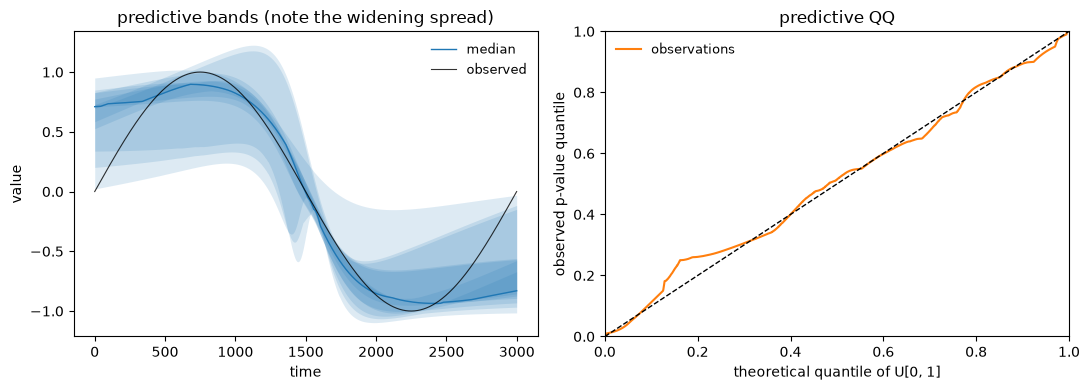

In [4]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
plot_timeseries(bands, gpu.ensemble_.quantiles, observed=y, ax=a0)
a0.set_title('predictive bands (note the widening spread)')
plot_qq(gpu.predictive_pvalues(X, y), ax=a1)
a1.set_title('predictive QQ')
fig.tight_layout()

The bands widen with `x`, matching the heteroscedastic noise — GPU adapts the distribution shape without being told to. Next: a real seasonal forecast (`01_seasonal_forecast`), a custom model (`02_custom_model`), and diagnostics / model selection (`03_diagnostics`).